# Expected light yield

In [1]:
from pathlib import Path
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt

DOCS = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(DOCS / 'scripts'))
import physics
importlib.reload(physics)
from physics import interp_dedx, recombination_factor, simulate_yield

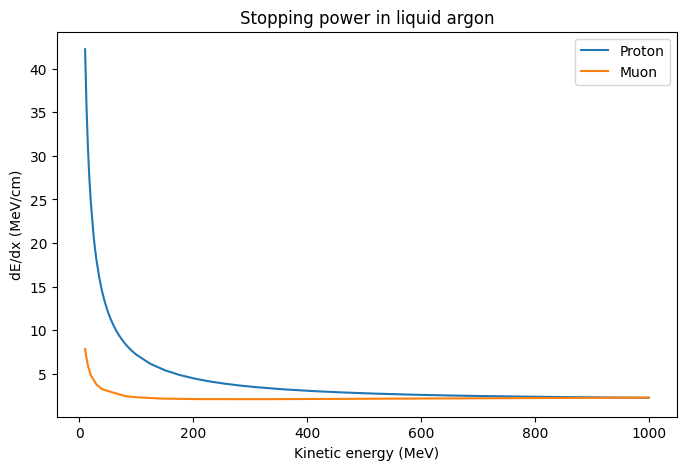

In [2]:
# First look at the stopping powers used by the calculation
ke = np.linspace(10, 1000, 400)
proton_dedx = np.array([interp_dedx(value, 'proton') for value in ke])
muon_dedx = np.array([interp_dedx(value, 'muon') for value in ke])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ke, proton_dedx, label='Proton')
ax.plot(ke, muon_dedx, label='Muon')
ax.set(xlabel='Kinetic energy (MeV)', ylabel='dE/dx (MeV/cm)', title='Stopping power in liquid argon')
ax.legend()
plt.show()

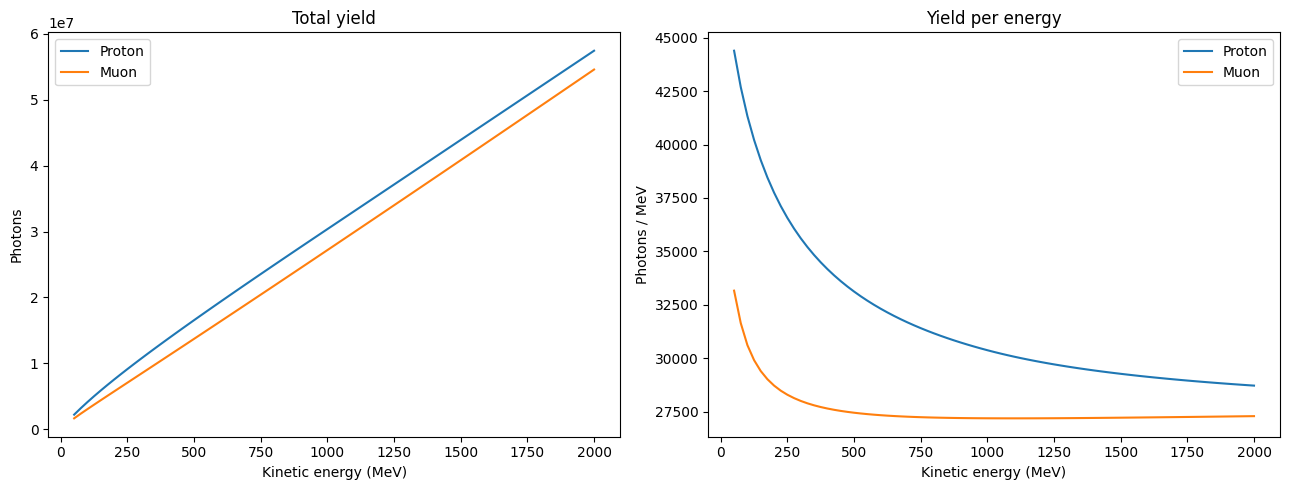

In [3]:
# Integrate the yield for stopping particles
ke_points = np.arange(50, 2001, 25)
proton_yield = np.array([simulate_yield(value, 'proton') for value in ke_points])
muon_yield = np.array([simulate_yield(value, 'muon') for value in ke_points])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(ke_points, proton_yield, label='Proton')
axes[0].plot(ke_points, muon_yield, label='Muon')
axes[0].set(xlabel='Kinetic energy (MeV)', ylabel='Photons', title='Total yield')
axes[1].plot(ke_points, proton_yield / ke_points, label='Proton')
axes[1].plot(ke_points, muon_yield / ke_points, label='Muon')
axes[1].set(xlabel='Kinetic energy (MeV)', ylabel='Photons / MeV', title='Yield per energy')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()